In [97]:
import hashlib,os,tarfile,zipfile,requests

from matplotlib.pyplot import xlabel, yscale

In [98]:
#@save
DATA_HUB = dict()
DATA_URL = 'https://d2l-data.s3-accelerate.amazonaws.com/'  # 大概率url错了

In [99]:
def download(name,cache_dir=os.path.join('..','data')):  #@save
    assert name in DATA_HUB,f'{name}不存在于{DATA_HUB}'
    url,sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir,exist_ok=True)
    fname = os.path.join(cache_dir,url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname,'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname

    print(f'正在从{url}下载{fname}')
    r = requests.get(url,stream=True,verify=True)
    with open(fname,'wb') as f:
        f.write(r.content)
    return fname

In [100]:
def download_extract(name,folder=None):  #@save
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir,ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname,'r')
    elif ext in ['.tar','.gz']:
        fp = tarfile.open(fname,'r')
    else:
        assert False, "只有zip/tar文件可以解压缩"
    fp.extractall(base_dir)
    return os.path.join(base_dir,folder) if folder else base_dir

In [101]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

In [102]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [103]:
print(train_data.shape)

(1460, 81)


In [104]:
print(test_data.shape)

(1459, 80)


In [105]:
print(train_data.iloc[0:4,[0,1,2,3,-3,-2,-1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [106]:
all_features = pd.concat((train_data.iloc[:,1:-1],test_data.iloc[:,1:]))  # 剔除无用标签

In [107]:
numeric_features = all_features.dtypes[all_features.dtypes!='object'].index
all_features[numeric_features] = all_features[numeric_features].apply(lambda x:(x-x.mean()) / (x.std()))
all_features[numeric_features] = all_features[numeric_features].fillna(0)  # 替换缺失值

In [108]:
all_features = pd.get_dummies(all_features,dummy_na=True,dtype=np.float32)  # 强制类型转换
all_features.shape  # 创建独热编码 扩展成列

(2919, 330)

In [109]:
print(all_features.dtypes[all_features.dtypes == 'object'])

Series([], dtype: object)


In [110]:
print(all_features.dtypes.value_counts())
print(all_features.to_numpy().dtype)

float32    294
float64     36
Name: count, dtype: int64
float64


In [111]:
n_train =  train_data.shape[0]
train_features = torch.tensor(all_features[:n_train].values,dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values,dtype=torch.float32)
train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1,1),dtype=torch.float32)

In [112]:
loss = nn.MSELoss()
in_features = train_features.shape[1]

In [113]:
def get_net():
    net = nn.Sequential(nn.Linear(in_features,1))
    return net

In [114]:
def log_rmse(net,features,labels):
    clipped_preds = torch.clamp(net(features),1,float('inf'))  # 1或者不变
    rmse = torch.sqrt(loss(torch.log(clipped_preds),torch.log(labels)))  # 对数空间的均方根误差
    return rmse.item()  # 张量变数字

In [115]:
def train(net, train_features, train_labels, test_features, test_labels, num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features,train_labels),batch_size)
    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)
    for epoch in range(num_epochs):
        for X, Y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), Y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

In [116]:
def get_k_fold_data(k,i,X,y):
    assert k > 1

    fold_size = X.shape[0]//k
    X_train,y_train,y_valid,X_valid = None,None,None,None
    for j in range(k):
        idx = slice(j*fold_size,(j+1)*fold_size)
        X_part,y_part = X[idx,:],y[idx]
        if j == i:
            X_valid,y_valid = X_part,y_part
        elif X_train is None:
            X_train,y_train = X_part,y_part
        else:
            X_train = torch.cat([X_train,X_part],0)  # 第零维拼接
            y_train = torch.cat([y_train,y_part],0)
    return X_train, y_train, X_valid, y_valid

In [117]:
def k_fold(k,x_train,y_train,num_epochs,learning_rate,weight_decay,batch_size):
    train_l_sum,valid_l_sum = 0,0
    for i in range(k):
        data = get_k_fold_data(k,i,x_train,y_train)
        net = get_net()
        train_ls,valid_ls = train(net,*data,num_epochs,learning_rate,weight_decay,batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            d2l.plot(list(range(1,num_epochs+1)),[train_ls,valid_ls],xlabel='epoch',ylabel='rmse',xlim=[1,num_epochs],legend=['train','valid'],yscale='log')
        print(f'折{i+1},训练log rmse{float(train_ls[-1])},',f'验证log rmse{float(valid_ls[-1])}')
    return train_l_sum/k,valid_l_sum/k

折1,训练log rmse0.16979306936264038, 验证log rmse0.15645600855350494
折2,训练log rmse0.16245754063129425, 验证log rmse0.1921577900648117
折3,训练log rmse0.16415464878082275, 验证log rmse0.16858509182929993
折4,训练log rmse0.16821293532848358, 验证log rmse0.15469764173030853
折5,训练log rmse0.1635715216398239, 验证log rmse0.1830742061138153
5-折验证:平均训练log rmse:0.165638, 平均验证log  rmse:0.170994


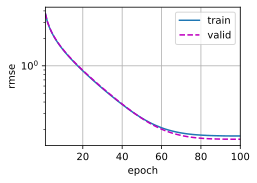

In [121]:
k,num_epochs,lr,weight_decay,batch_size = 5,100,5,0,64
train_l,valid_l = k_fold(k,train_features,train_labels,num_epochs,lr,weight_decay,batch_size)
print(f'{k}-折验证:平均训练log rmse:{float(train_l):f},',f'平均验证log  rmse:{float(valid_l):f}')  # 指标越小越好

In [124]:
def train_and_pred(train_features,test_features,train_labels,test_labels,num_epochs,lr,weight_decay,batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features,train_labels,None,None,num_epochs,lr,weight_decay,batch_size)
    d2l.plot(np.arange(1,num_epochs+1),[train_ls],xlabel='epoch',ylabel='log rmse',xlim=[1,num_epochs],yscale='log')
    print(f'训练log rmse:{float(train_ls[-1]):f}')
    preds = net(test_features).detach().numpy()
    test_data['SalePrice'] = pd.Series(preds.reshape(1,-1)[0])
    submission = pd.concat([test_data['Id'],test_data['SalePrice']],axis=1)
    submission.to_csv('submission.csv',index=False)

训练log rmse:0.162610


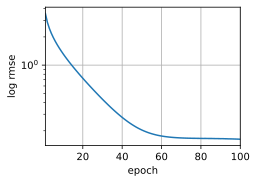

In [125]:
train_and_pred(train_features,test_features,train_labels,test_data,num_epochs,lr,weight_decay,batch_size)